<a href="https://colab.research.google.com/github/Josh-Talks/EPUG-Training_a_NN_with_pytorch/blob/main/U-Net_extension.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extension: Something slightly more realistic

## Training a U-Net on Nuclei data

The [U-net](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/) is a very popular model architecture for segmentation in bioimage analysis.
Here, we will train a 2D U-net for nuclei segmentation, using data from the [Kaggle Nucleus Segmentation challenge](https://www.kaggle.com/c/data-science-bowl-2018).

## Loading the data

In [1]:
import os

if os.getenv("COLAB_RELEASE_TAG"):
    data_dir = "./data"
    #check if images and utils.py are already downloaded, if not download them
    if not os.path.exists("./images"):
        !wget https://github.com/Josh-Talks/EPUG-Training_a_NN_with_pytorch/tree/main/images
    if not os.path.exists("./utils.py"):
        !wget https://github.com/Josh-Talks/EPUG-Training_a_NN_with_pytorch/raw/refs/heads/main/utils.py
else:
    #data_dir = "./data/"
    data_dir = "/scratch/talks/data/"

In [2]:
# # Data download
# !cd ./data
# !wget https://raw.githubusercontent.com/AakashSudhakar/2018-data-science-bowl/master/compressed_files/stage1_train.zip -c

In [3]:
# from utils import extract, get_folder_names
# from zipfile import ZipFile
# zip_path = os.path.join(data_dir, "stage1_train.zip")
# folder_names = get_folder_names(zip_path)
# extract(ZipFile(zip_path), os.path.join(data_dir, 'nuclei_train_data'), folder_names[:400])
# extract(ZipFile(zip_path), os.path.join(data_dir, 'nuclei_val_data'), folder_names[400:])

## Nuclei Dataset

In [2]:
import os
from torchvision import transforms
from scipy.ndimage import binary_erosion
from PIL import Image
import torch
# datasets have to be sub-classes from torch.util.data.Dataset
from torch.utils.data import Dataset

# any PyTorch dataset class should inherit the initial torch.utils.data.Dataset
class NucleiDataset(Dataset):
    """ A PyTorch dataset to load cell images and nuclei masks """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir  # the directory with all the training samples
        self.samples = os.listdir(root_dir) # list the samples
        self.transform = transform    # transformations to apply to both inputs and targets
        #  transformations to apply just to inputs
        self.inp_transforms = transforms.Compose([transforms.Grayscale(), # some of the images are RGB
                                                  transforms.ToTensor(),
                                                  transforms.Normalize([0.5], [0.5])])
        # transformations to apply just to targets
        self.mask_transforms = transforms.ToTensor()

    # get the total number of samples
    def __len__(self):
        return len(self.samples)

    # fetch the training sample given its index
    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.samples[idx],
                                'images', self.samples[idx]+'.png')
        # we'll be using Pillow library for reading files
        image = Image.open(img_path)
        image = self.inp_transforms(image)
        masks_dir = os.path.join(self.root_dir, self.samples[idx], 'masks')
        # masks directory has multiple images - one mask per nucleus
        masks_list = os.listdir(masks_dir)
        # create an empty array
        mask = torch.zeros_like(image)
        # iterate through the images to sum them up to one mask
        for mask_name in masks_list:
            one_nuclei_mask = Image.open(os.path.join(masks_dir, mask_name))
            # erode the image by one pixel
            # TASK: guess why is this done?
            one_nuclei_mask = binary_erosion(one_nuclei_mask)
            one_nuclei_mask = self.mask_transforms(one_nuclei_mask)
            # add this nucleus to the mask
            mask += one_nuclei_mask
        if self.transform is not None:
            image, mask = self.transform([image, mask])
        
        # add singleton channel dimension to the mask
        #mask = mask.unsqueeze(0)
        return image, mask

In [3]:
TRAIN_DATA_PATH = os.path.join(data_dir, 'nuclei_train_data')
train_data = NucleiDataset(TRAIN_DATA_PATH)

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def show_random_dataset_image(dataset):
    idx = np.random.randint(0, len(dataset))    # take a random sample
    img, mask = dataset[idx]                    # get the image and the nuclei masks
    f, axarr = plt.subplots(1, 2)               # make two plots on one figure
    axarr[0].imshow(img[0].squeeze(), cmap="gray")                     # show the image
    axarr[1].imshow(mask[0].squeeze(), interpolation='none')                    # show the masks
    _ = [ax.axis('off') for ax in axarr]        # remove the axes
    print('Image size is %s' % {img[0].shape})
    plt.show()

Image size is {torch.Size([256, 256])}


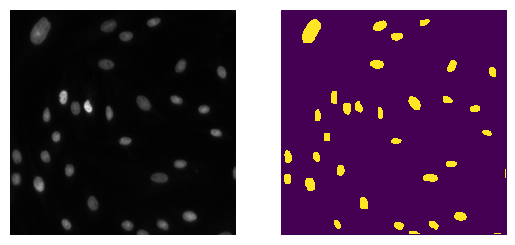

In [5]:
show_random_dataset_image(train_data)

If you visualized many images, you will see that some of them are fairly large. What happens if we load them into memory and feed them to the mode? We might run out of memory. 
Consequently, when training networks on images or volumes one has to be careful about the input sizes. Also, for training in batches, i.e. feeding multiple images to the network at once, all images in the batch have to be of the same size. Hence all images need to be cropped or rescaled to the same size.

For this exercise we implement a class that will apply a transformation `random crop`. Notice that we apply it to images and masks simultaneously to make sure they correspond despite the randomness.

In case anybody is wondering why we have to bother to write a whole class for it instead of simply cropping the images directly in the dataset: we want to keep the code modular. We want to write one dataset object, and then we can try all the possible transforms with this one dataset. Similarly, we want to write one `RandomCrop` transform object, and then we can reuse it for any other image datasets we night have in the future.

In [6]:
class RandomCrop(object):
    """Crop randomly the input image and the output mask"""
    def __init__(self, crop_size):
        # check if the crop size is of a valid type
        assert isinstance(crop_size, (int, tuple, list))
        if isinstance(crop_size, int):
            # if the crop size is an integer, we use the same for both dimensions
            self.output_size = (crop_size, crop_size)
        else:
            assert len(crop_size) == 2
            self.crop_size = crop_size

    # this function makes our class callable 
    def __call__(self, sample):
        # we need to crop both input and mask at the same time
        assert len(sample) == 2
        image, mask = sample
        # the first dimension is channels, then width, then height
        w, h = image.shape[1:]
        new_w, new_h = self.output_size
        # choose a random place to crop
        top = np.random.randint(0, h - new_h) if h - new_h > 0 else 0
        left = np.random.randint(0, w - new_w) if w - new_w > 0 else 0
        # crop and return
        image = image[:, left: left + new_w, top: top + new_h]
        mask = mask[:, left: left + new_w, top: top + new_h]
        return image, mask

In [7]:
from torch.utils.data import DataLoader

train_data = NucleiDataset(TRAIN_DATA_PATH, RandomCrop(256))
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=8)

Image size is {torch.Size([256, 256])}


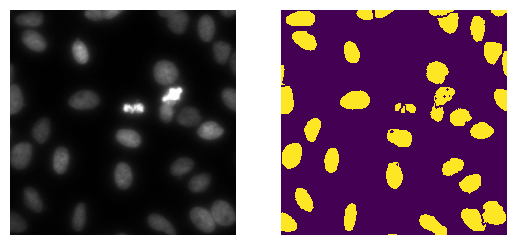

In [8]:
show_random_dataset_image(train_data)

In [9]:
VAL_DATA_PATH = os.path.join(data_dir, 'nuclei_val_data')
val_data = NucleiDataset(VAL_DATA_PATH, RandomCrop(256))
val_loader = DataLoader(val_data, batch_size=32, num_workers=8)

Image size is {torch.Size([256, 256])}


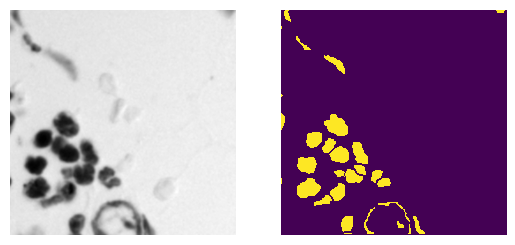

In [10]:
show_random_dataset_image(val_data)

## The model: U-net

Now we need to define the architecture of the model to use. This time we will use a [U-Net](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/) that has proven to steadily outperform the other architectures in segmenting biological and medical images.

The image of the model precisely describes all the building blocks you need to use to create it. All of them can be found in the list of PyTorch layers (modules) [here](https://pytorch.org/docs/stable/nn.html#convolution-layers).

The U-net has an encoder-decoder structure:
In the encoder pass, the input image is successively downsampled via max-pooling. In the decoder pass it is upsampled again via transposed convolutions.
In adddition, it has skip connections, that bridge the output from an encoder to the corresponding decoder.

<img src="./images/u-net.png" width="400" height="300">

[Image reference](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/)


In [11]:
import torch.nn as nn

class UNet(nn.Module):
    """ UNet implementation
    Arguments:
      in_channels: number of input channels
      out_channels: number of output channels
      final_activation: activation applied to the network output
    """
    
    # _conv_block and _upsampler are just helper functions to
    # construct the model.
    # encapsulating them like so also makes it easy to re-use
    # the model implementation with different architecture elements
    
    # Convolutional block for single layer of the decoder / encoder
    # we apply to 2d convolutions with relu activation
    def _conv_block(self, in_channels, out_channels):
        return nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                             nn.ReLU(),
                             nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                             nn.ReLU())       


    # upsampling via transposed 2d convolutions
    def _upsampler(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels,
                                kernel_size=2, stride=2)
    
    def __init__(self, in_channels=1, out_channels=1, 
                 final_activation=None):
        super().__init__()
        
        # the depth (= number of encoder / decoder levels) is
        # hard-coded to 4
        self.depth = 4

        # the final activation must either be None or a Module
        if final_activation is not None:
            assert isinstance(final_activation, nn.Module), "Activation must be torch module"
        
        # all lists of conv layers (or other nn.Modules with parameters) must be wraped
        # itnto a nn.ModuleList
        
        # modules of the encoder path
        self.encoder = nn.ModuleList([self._conv_block(in_channels, 16),
                                      self._conv_block(16, 32),
                                      self._conv_block(32, 64),
                                      self._conv_block(64, 128)])
        # the base convolution block
        self.base = self._conv_block(128, 256)
        # modules of the decoder path
        self.decoder = nn.ModuleList([self._conv_block(256, 128),
                                      self._conv_block(128, 64),
                                      self._conv_block(64, 32),
                                      self._conv_block(32, 16)])
        
        # the pooling layers; we use 2x2 MaxPooling
        self.poolers = nn.ModuleList([nn.MaxPool2d(2) for _ in range(self.depth)])
        # the upsampling layers
        self.upsamplers = nn.ModuleList([self._upsampler(256, 128),
                                         self._upsampler(128, 64),
                                         self._upsampler(64, 32),
                                         self._upsampler(32, 16)])
        # output conv and activation
        # the output conv is not followed by a non-linearity, because we apply
        # activation afterwards
        self.out_conv = nn.Conv2d(16, out_channels, 1)
        self.activation = final_activation
    
    def forward(self, input):
        x = input
        # apply encoder path
        encoder_out = []
        for level in range(self.depth):
            x = self.encoder[level](x)
            encoder_out.append(x)
            x = self.poolers[level](x)

        # apply base
        x = self.base(x)
        
        # apply decoder path
        encoder_out = encoder_out[::-1]
        for level in range(self.depth):
            x = self.upsamplers[level](x)
            x = self.decoder[level](torch.cat((x, encoder_out[level]), dim=1))
        
        # apply output conv and activation (if given)
        x = self.out_conv(x)
        if self.activation is not None:
            x = self.activation(x)
        return x

## Loss and distance metrics

Next, we need to define the loss function - a metric that will tell us how close we are to the desired output. This metric should be differentiable, since it needs to be backpropagated. The are [multiple losses](https://lars76.github.io/2018/09/27/loss-functions-for-segmentation.html) we could use for the segmentation task.

Take a moment to think which one is better to use for our exercise. If you are not sure, don't forget that you can always google! Before you start implementing the loss yourself, take a look at the [losses](https://pytorch.org/docs/stable/nn.html#loss-functions) already implemented in PyTorch. You can also look for implementations on GitHub.

In [12]:
loss_function = nn.BCELoss()

We will use the [Dice Coefficeint](https://en.wikipedia.org/wiki/S%C3%B8rensen%E2%80%93Dice_coefficient) to evaluate the network predictions.
We can use it for validation if we interpret set $a$ as predictions and $b$ as labels. It is often used to evaluate segmentations with sparse foreground, because the denominator normalizes by the number of foreground pixels.
The Dice Coefficient is closely related to Jaccard Index / Intersection over Union.

In [13]:
# sorensen dice coefficient implemented in torch
# the coefficient takes values in [0, 1], where 0 is
# the worst score, 1 is the best score
class DiceCoefficient(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps
        
    # the dice coefficient of two sets represented as vectors a, b ca be 
    # computed as (2 *|a b| / (a^2 + b^2))
    def forward(self, prediction, target):
        intersection = (prediction * target).sum()
        denominator = (prediction * prediction).sum() + (target * target).sum()
        return (2 * intersection / denominator.clamp(min=self.eps))

## Running Training

As we train we probably want to save our model as it progresses or at least save the final output so that we can use it in the future. We can do this by saving the model 'checkpoints' that save the current state of the model and the optimizer. This allows us to load our pre-trained model and either directly use it or even continue further training.  

In [14]:
def save_checkpoint(model, optimizer, epoch, save_path):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        },
        save_path,
    )

Below we define a full training script, using all the knowledge we have gained from the notebook so far, combining it together into a single function that will train a given model for a set number of epochs, validating and logging along the way and svaing the best model as we train in a checkpoint file.

In [16]:
# instantiate the tensorboard logger that will be passed to the
# training and validation functions
from torch.utils.tensorboard import SummaryWriter
lg_tb_logger = SummaryWriter('runs/log_reg')

# this magic command will open tensorboard inside of our notebook
# click on the refresh symbol after the training (see below) has finished
# to see the training progress log
%load_ext tensorboard
%tensorboard --logdir runs --port 6006

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 1505760), started 0:08:08 ago. (Use '!kill 1505760' to kill it.)

In [17]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import trange
from utils import train, validate


def run_nuclei_training(
    model, 
    optimizer, 
    train_loader, 
    val_loader,
    loss_function,
    metric,
    device, 
    name, 
    n_epochs
):
    """Complete training logic"""

    best_accuracy = 0.0

    # loss_function = nn.NLLLoss()
    loss_function.to(device)

    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    # Logging to tensorboard
    tb_logger = SummaryWriter(f'runs/{name}')

    # Path to save model checkpoint
    checkpoint_dir = "./checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = f"{checkpoint_dir}/best_checkpoint_{name}.pt"
    

    for epoch in trange(n_epochs):
        train(
            model,
            train_loader,
            loss_function,
            optimizer,
            device,
            epoch,
            tb_logger,
            task="segmentation"
        )
        step = (epoch + 1) * len(train_loader)

        _, _, val_metric = validate(
            model,
            val_loader,
            loss_function,
            device,
            step,
            metric=metric,
            tb_logger=tb_logger,
            task="segmentation"
        )
        scheduler.step(val_metric)

        # otherwise, check if this is our best epoch
        if val_metric > best_accuracy:
            # if it is, save this check point
            best_accuracy = val_metric
            save_checkpoint(model, optimizer, epoch, checkpoint_path)


    return checkpoint_path

## Training the U-Net

In [18]:
# check if we have gpu support
# if you run these exercises on colab, you can use the free colab gpus:
# (however they are not activated by default)
# to activate the gpu on colab, go to 'Runtime->Change runtime type'. 
# Then select 'GPU' in 'Hardware accelerator' and click 'Save'
have_gpu = torch.cuda.is_available()
# we need to define the device for torch, yadda yadda
if have_gpu:
    print("GPU is available")
    device = torch.device('cuda')
else:
    print("GPU is not available, training will run on the CPU")
    device = torch.device('cpu')

GPU is available


In [19]:
from torch.optim import Adam

unet_model = UNet(in_channels=1, out_channels=1, final_activation=nn.Sigmoid())
unet_model.to(device)

unet_optimizer = Adam(unet_model.parameters(), lr=1e-3)
metric = DiceCoefficient()
loss_function = nn.BCELoss()

checkpoint_path = run_nuclei_training(
    model=unet_model,
    optimizer=unet_optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    metric=metric,
    device=device,
    name="unet",
    n_epochs=2
)

100%|██████████| 2/2 [00:42<00:00, 21.46s/it]


## Evaluate performance

Lets load the model from a checkpoint

In [20]:
checkpoint_path = "/g/kreshuk/talks/EPUG-Training_a_NN_with_pytorch/checkpoints/best_checkpoint_unet_e20.pt"
ckpt = torch.load(checkpoint_path, weights_only=False)
print(ckpt.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict'])


In [21]:
## Initialise model
model = UNet(in_channels=1, out_channels=1, final_activation=nn.Sigmoid())
# load the model weights from the checkpoint
model.load_state_dict(ckpt['model_state_dict'])
model.to(device)

UNet(
  (encoder): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
    (3): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (base): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [22]:
input, output = next(iter(val_loader))
prediction = model(input.to(device))

In [23]:
def plot_prediction(input, output, prediction):
    f, axarr = plt.subplots(1, 3)
    axarr[0].imshow(input[0].squeeze(), cmap="gray")
    axarr[0].set_title("Input image")
    axarr[1].imshow(output[0].squeeze(), interpolation='none')
    axarr[1].set_title("Ground truth mask")
    axarr[2].imshow(prediction[0].squeeze().cpu().detach(), interpolation='none')
    axarr[2].set_title("Predicted mask")
    _ = [ax.axis('off') for ax in axarr]
    plt.show()

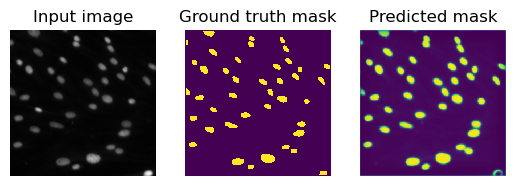

In [24]:
plot_prediction(input, output, prediction)

In [25]:
DICE_score = DiceCoefficient()(prediction, output.to(device))
print("DICE score is %f" % DICE_score)

DICE score is 0.737632
